In [13]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider, fixed

import francois_garisson as fg 
import sonar_equation as SE


# An introduction to underwater accoustics: The active sonar equation 

At the heart of telecommunications lies the link budget, an essential tool for dimensioning systems based on target performance, such as received signal strength. Its acoustic counterpart is the SONAR equation, which serves the same purpose by characterizing acoustic systems through the lens of marine propagation parameters.

To derive the active sonar equation, we first define the Signal-to-Noise Ratio (SNR) as:
$$ SNR_{\text{dB}} = S_{\text{T, dB}} - B_{\text{L, dB} \tag{1.0}}$$

Where $S_{\text{T, dB}}$ represents the received signal level and $B_{\text{L, dB}}$ the background noise level, both expressed in dB.

The received signal $S_{\text{T, dB}}$ can be expanded as follows:
$$S_{\text{T, dB}} = SL_{\text{dB}} - 2 \cdot TL_{\text{dB}} + TS_{\text{dB}} \tag{1.1}$$

In this expression, $SL_{\text{dB}}$ is the Source Level, $TL_{\text{dB}}$ is the Transmission Loss (multiplied by two to account for the round-trip path), and $TS_{\text{dB}}$ is the Target Strength.

Similarly, the background level $B_{\text{L, dB}}$ is defined by:
$$B_{\text{L, dB}} = NL_{\text{dB}} - DI_{\text{dB}} \tag{1.2}$$

Where $NL_{\text{dB}}$ is the Noise Level and $DI_{\text{dB}}$ is the Directivity Index.

By substituting equations $(1.1)$ and $(1.2)$ into $(1.0)$, we obtain the complete Active Sonar Equation:
$$SNR_{\text{dB}} = SL_{\text{dB}} - 2 \cdot TL_{\text{dB}} + TS_{\text{dB}} - (NL_{\text{dB}} - DI_{\text{dB}}) \tag{1.3}$$

The goal of this Notebook is to explore the various components of this equation to understand how the propagation channel and the system's characteristics influence communication performance. We will conduct this study iteratively; parameters not currently under investigation will be held constant at specified values.

## Transmission Loss (TL)

--- 

This parameter represents the attenuation of the acoustic wave as it propagates through the medium. Transmission losses are generally decomposed into two distinct phenomena: geometrical spreading losses and absorption spreading losses. 

### Geometric spreading loss

If we assume a homogeneous and infinite medium—a valid hypothesis for deep-sea transmissions far from boundaries—and a point source radiating uniformly in all directions, the intensity of the acoustic wave decreases as the wavefront expands.While the total energy is conserved, the power is distributed over the surface of an expanding sphere with radius $R$. We define the Transmission Loss ($TL$) as follows:
$$TL_{\text{dB}} = 10 \log_{10}\left(\frac{I_0}{I}\right) \tag{1.4}$$
Where $I_0$ is the reference intensity (measured at 1 meter from the source), defined as $I_0 = \frac{P}{4 \pi (1)^2}$ (with $P$ being the emitted power). The intensity $I$ at a given radius $R$ is $I = \frac{P}{4 \pi R^2}$, as the power $P$ remains constant across the expanding sphere. We can then rewrite $(1.4)$ as:

$$TL_{\text{dB}} = 10 \log_{10}\left(\frac{\frac{P}{4 \pi}}{\frac{P}{4 \pi R^2}}\right) = 20 \log_{10}(R) \tag{1.5}$$

Where $R$ is the distance traveled by the acoustic wave (in meters).In shallow water environments, the acoustic wave is bounded by the sea surface and the seabed. Beyond a certain distance (roughly equal to the water depth), the wavefront can no longer expand vertically and instead spreads horizontally.In this configuration, the acoustic energy is distributed over the surface of a cylinder ($2\pi R \cdot H$, where $H$ is the water depth) rather than a sphere. Consequently, the intensity decreases more slowly with distance. Similarly, we define the Transmission Loss for the cylindrical case as:
$$TL_{\text{dB}} = 10 \log_{10}\left(\frac{\frac{P}{2 \pi H}}{\frac{P}{2 \pi R H}}\right) = 10 \log_{10}(R) \tag{1.6}$$


**Experiment**: Visualize the SNR evolution in both spherical and cylindrical spreading case

First of all, we'll initialize an instance of the sonar equation with the following parameters: 

- $SL_{dB} = 200 dB$, 
- $TS_{dB} = 15$,
- $NL_{dB} = 60$,
- $DI_{dB} = 0$ (the case of an omnidirectional hydrophone), 
- $DT_{dB} = 10 dB$ 




In [14]:
sonar_equation = SE.SonarEquation(200, 15, 60, 0, 10)

By plotting the SNR curves for both cases, we can clearly observe the impact of the propagation medium on system performance. Due to the better conservation of acoustic intensity in the cylindrical spreading scenario, the SNR remains above the detection threshold for a significantly longer distance compared to the spherical case.

In practical terms, this means that in shallow water or acoustic waveguides, a sonar system will have a much greater operational range because the energy is "trapped" and directed, rather than being lost in all directions.

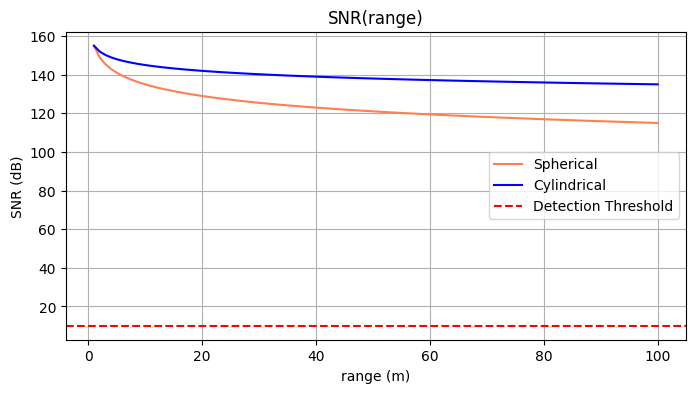

In [15]:
distance = np.linspace(1, 100, 100)
SNR_s = sonar_equation.compute_SNR(distance=distance, geometrical_model='spherical')
SNR_c = sonar_equation.compute_SNR(distance=distance, geometrical_model='cylindrical')
plt.figure(figsize=(8, 4))
plt.plot(distance, SNR_s, color='coral', label='Spherical')
plt.plot(distance, SNR_c, color='blue', label='Cylindrical')
plt.axhline(y=sonar_equation.detection_threshold, color='red', linestyle='--', label='Detection Threshold')
plt.title("SNR(range)")
plt.xlabel("range (m)")
plt.ylabel("SNR (dB)")
plt.grid(True)
plt.legend()
plt.show()

### Absorption Loss
In addition to geometric spreading, acoustic energy is dissipated through absorption. This phenomenon is driven by the viscosity of pure water (which increases with the square of the frequency) and chemical relaxation processes involving ions in seawater, such as magnesium sulfate ($MgSO_4$) and boric acid ($B(OH)_3$).This loss is characterized by the absorption coefficient $\alpha$, expressed in dB/km. In our link budget, the total absorption loss is defined as:
$$AL_{\text{dB}} = \alpha \cdot R \cdot 10^{-3} \tag{1.7}$$
(Note: the $10^{-3}$ factor is used if $R$ is in meters and $\alpha$ in dB/km).
The general form for the absorption coefficient is:
$$\alpha = \sum_{i=1}^{2} \frac{A_i f_i f^2}{f_i^2 + f^2} + A_3 f^2 \tag{1.8}$$
To model these contributions accurately, we use the Francois-Garrison model (1982), which decomposes $\alpha$ into three main terms:

*1. Boric Acid Contribution*

This component is dominant at low frequencies (below 1 kHz) and depends heavily on the water's pH:
$$C_1 = \frac{8.86}{c} 10^{(0.78 \cdot pH - 5)}\\
f_1 = 2.8 \sqrt{\frac{S}{35}} \cdot 10^{(4 - \frac{1245}{T + 273})}$$
Where $T$ is the temperature in °C and $S$ is the salinity in p.s.u.

*2. Magnesium Sulfate Contribution*

This term dominates the mid-frequency range (1 kHz to 100 kHz):

$$C_2 = 21.44 \frac{S}{c}(1 + 0.025 T) \cdot P_2\\P_2 = 1 - 1.37 \times 10^{-4} z + 6.2 \times 10^{-9} z^2\\ 
f_2 = \frac{8.17 \times 10^{(8 - \frac{1990}{T+273})}}{1 + 0.0018(S-35)}$$

Where $z$ is the depth in meters.

*3. Pure Water Contribution*

At very high frequencies (above several hundred kHz), the viscosity of pure water becomes the primary cause of attenuation:
$$C_3 = A_3 P_3\\
P_3 = 1 - 3.83 \times 10^{-5} z + 4.9 \times 10^{-10} z^2\\
A_3 = \begin{cases} 
4.937 \times 10^{-4} - 2.59 \times 10^{-5} T + 9.11 \times 10^{-7} T^2 - 1.5 \times 10^{-8} T^3 & \text{if } T \leq 20 \\\\ 
3.964 \times 10^{-4} - 1.146 \times 10^{-5} T + 1.45 \times 10^{-7} T^2 - 6.5 \times 10^{-10} T^3 & \text{if } T > 20 
\end{cases}$$

**Experimentation:** Describe the evolution of the $\alpha$ coefficicent as a function of frequency depending on both water depth and temperature. 

We firstly visualize that $\alpha$ is increasing with frequency but also, it is lower at greater depth, which shows that the absorption loss is less significant in deep water. 

In [16]:
interact(fg.update_plot, 
         f_khz=FloatSlider(min=1, max=500, step=1, value=50, description='Frequency (kHz):'), 
         T_min=fixed(0), T_max=fixed(35), z_min=fixed(0), z_max=fixed(5000), nb_points=fixed(100), c = fixed(1500), S = fixed(35), pH = fixed(7.5))

interactive(children=(FloatSlider(value=50.0, description='Frequency (kHz):', max=500.0, min=1.0, step=1.0), O…

<function francois_garisson.update_plot(f_khz, T_min=0, T_max=35, z_min=0, z_max=5000, nb_points=100, c=1500, S=35, pH=7.5)>

We will now analyze the impact of several parameters on the absorption coefficient $\alpha$ and thus on the SNR evolution over range since the absorption loss is range dependent. We will focus on the influence of temperature, depth, salinity and frequency.

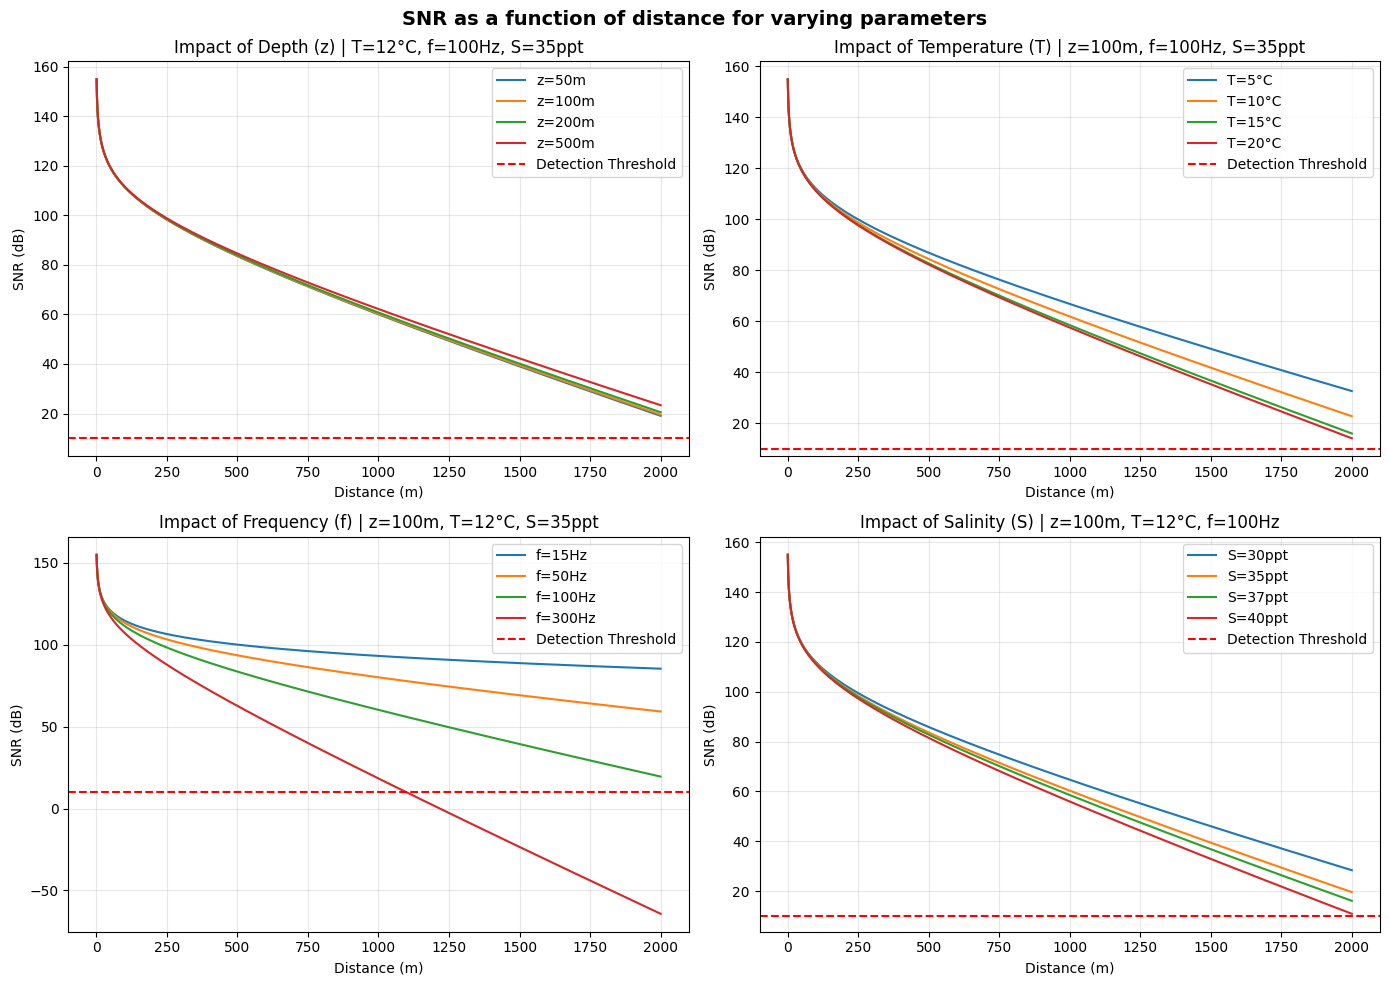

In [17]:

# Analyse de l'impact des paramètres z, T, f, S sur le SNR
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SNR as a function of distance for varying parameters', fontsize=14, fontweight='bold')

distance = np.linspace(1, 2000, 5000)

# Paramètres pour chaque variable
z_values = [50, 100, 200, 500]
T_values = [5, 10, 15, 20]
f_values = [15, 50, 100, 300]
S_values = [30, 35, 37, 40]

# 1. Impact du paramètre z (profondeur)
ax = axes[0, 0]
for z in z_values:
    sonar_equation.set_absorption_loss_const(c=1500, S=35, T=12, z=z, f=100)
    SNR = sonar_equation.compute_SNR(distance, absorption_loss=True)
    ax.plot(distance, SNR, label=f'z={z}m')
ax.axhline(y=sonar_equation.detection_threshold, color='red', linestyle='--', label='Detection Threshold')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('SNR (dB)')
ax.set_title('Impact of Depth (z) | T=12°C, f=100Hz, S=35ppt')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Impact du paramètre T (température)
ax = axes[0, 1]
for T in T_values:
    sonar_equation.set_absorption_loss_const(c=1500, S=35, T=T, z=100, f=100)
    SNR = sonar_equation.compute_SNR(distance, absorption_loss=True)
    ax.plot(distance, SNR, label=f'T={T}°C')
ax.axhline(y=sonar_equation.detection_threshold, color='red', linestyle='--', label='Detection Threshold')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('SNR (dB)')
ax.set_title('Impact of Temperature (T) | z=100m, f=100Hz, S=35ppt')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Impact du paramètre f (fréquence)
ax = axes[1, 0]
for f in f_values:
    sonar_equation.set_absorption_loss_const(c=1500, S=35, T=12, z=100, f=f)
    SNR = sonar_equation.compute_SNR(distance, absorption_loss=True)
    ax.plot(distance, SNR, label=f'f={f}Hz')
ax.axhline(y=sonar_equation.detection_threshold, color='red', linestyle='--', label='Detection Threshold')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('SNR (dB)')
ax.set_title('Impact of Frequency (f) | z=100m, T=12°C, S=35ppt')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Impact du paramètre S (salinité)
ax = axes[1, 1]
for S in S_values:
    sonar_equation.set_absorption_loss_const(c=1500, S=S, T=12, z=100, f=100)
    SNR = sonar_equation.compute_SNR(distance, absorption_loss=True)
    ax.plot(distance, SNR, label=f'S={S}ppt')
ax.axhline(y=sonar_equation.detection_threshold, color='red', linestyle='--', label='Detection Threshold')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('SNR (dB)')
ax.set_title('Impact of Salinity (S) | z=100m, T=12°C, f=100Hz')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# A corriger 

First of all, we will compute the SNR evolution with those fixed parameters: T = 12°C, S = 35 p.s.u, f = 100 kHz and different values for the depth (from 50 to 500m). Overall, can state that the SNR evolution is relativly close with each depth values. Even if we can see that the greater the depth is, the higher the SNR; which is consistent with the fact that the absorption loss is less significant in deep water. Eventually, we can conclude that the depth has a limited impact on the SNR evolution in this configuration. 

Then, we will fix z = 100m, f=100kHz and S = 35 p.s.u. Here we will evaluate the SNR with temperature values ranging to 5 to 20°C. We can clearly observe that the temperature has a more significant impact on the SNR than the depth. Indeed, we can clearly state that the higher te temperature is, lower the SNR. We can observe approximately a 20 dB difference at 2000 m range between the 5°C and the 20°C, which can have a major impact on the performance of the system. 

What is more, we want to characterize the impact of the frequency on the SNR evolution. Here we can clearly draw a trend where the frequency augmentation drastically limits the range of the system. We can for example obsreve that a 300 kHz signal will go bellow the detection threshold around 1000m, whil the 100 kHz will still remain above this threshold after 2000m range. With this observation, we can conclude that the frequency is a higly limiting factor for the system range performance. 

Eventaually, we observe the evolution of the salinity also has an impact on the SNR: the higher the slainity parameter is, the lower the SNR. This is consistent with the fact that the magnesium sulfate contribution to absorption loss is directly proportional to the salinity parameter.


To summarize, we have observed that all parameters ave an impact on the range performance but the frequency is the main limiting factor for the system range performance, followed by the temperature. The depth and salinity have a more limited impact on the SNR evolution. Still, it is import to note that the modelisation here is still quite simplified: indeed S, z and T are likely to evoluate with other parameter (for instance, the temperature is likely to decrease with depth) and thus, the impact of these parameters on the SNR evolution is likely to be more significant than what we have observed here.


Next: Modeling the noise level 